<a href="https://colab.research.google.com/github/rxphaelbihag/DS171-Intro-to-Supervised-Machine-Learning/blob/main/Least_Squares_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratory Exercise 1: Least Squares Linear Regression

Student No.: 2024-05203

Date: Sept. 25, 2026

## Import Libraries

In [16]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

## Data Loading
This approach allows for accessing the dataset without downloading it to the local computer.

In [17]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "insurance.csv"

# load the latest version
insurance_df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "abdullahcetin/mirichoi0218insurance",
  file_path,
)

/tmp/ipykernel_19593/1449635476.py:7: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  insurance_df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'mirichoi0218insurance' dataset.


In [18]:
insurance_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Since one of the independent variables is a categorical feature (`smoker`), we must encode it for the algorithm to recognize it. We do this by making `yes = 1` and `no = 0`

In [19]:
# dictionary for mapping
smoker_bool = {'yes': 1, 'no': 0}

insurance_df['smoker'] = insurance_df['smoker'].map(smoker_bool)

In [20]:
insurance_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,1,southwest,16884.92400
1,18,male,33.770,1,0,southeast,1725.55230
2,28,male,33.000,3,0,southeast,4449.46200
3,33,male,22.705,0,0,northwest,21984.47061
4,32,male,28.880,0,0,northwest,3866.85520


## Linear Regression Implementation

### Ordinary Least Squares Linear Regression

This implementation is done using the normal equation of regression coefficients vector $\hat{w}$ such that $$\hat{w}= ( X^{T} X)^{-1} X^Ty$$ where $X$ is the feature matrix and $y$ is the target vector. The dependent variable is `charges`, and the predictors are `age`, `bmi`, `children`, and `smoker`. Let $N$ be the number of samples.

In [21]:
# spliting the data to feature matrix X and target vector y
y = insurance_df['charges'].to_numpy()                             # y vector
X = insurance_df[['age', 'bmi', 'children', 'smoker']].to_numpy()  # X matrix

In [22]:
w_0 = np.ones(len(X))           # a vector of ones with length
X = np.column_stack((X, w_0))

In [23]:
# normal equation using numpy linear algebra
w_hat = np.linalg.inv(X.T @ X) @ X.T @ y

### Weighted Linear Regression
This model is implemented by calculating an individual weight for each samples in the dataset. The weight $\beta_{p}$ is equal to the frequency profile $p$ appears in the dataset. A profile consists of (age, children, smoker). So if the profile age 34, 3 children, and is a smoker appears five times in the dataset, those profiles are given a weight of 5.

The code implementation of this is to create a temporary submatrix of training X such that its features are only age, children, and smoker, and contains 70% of samples of the entire dataset. Each record this matrix are then converted to tuples to initiate the computation of profile frequencies using `Counter` from Python's built-in library `collections`. Using the frequency as a dictionary, the weight vector $\beta$ is built by iterating over all the rows of the training matrix and assigning the weights by index.

In [24]:
from collections import Counter

# Creates a temporary training submatrix of X, 70%
X_train_temp = np.delete(X, 1, axis=1)
# Converts all records to tuple
X_train_temp = list(map(tuple, X_train_temp))
# Calculates the frequencies of each record
frequency = dict(Counter(X_train_temp))

In [25]:
# weight vector beta
beta = []

# iterating over all the records to assign a weight by index
for p in X_train_temp:
    beta.append(frequency[p])

# convert to numpy array
beta = np.array(beta)

The weighted regression coefficient vector $\hat{w}_{weighted}$ is given by $$\hat{w}_{weighted}= (X^T WX)^{-1} X^T Wy$$ such that $X$ is the feature matrix, $y$ is the target vector, and $W$ is the diagonal matrix of weights $\beta_{p}$.

In [26]:
# Diagonal matrix of beta, weights
W = np.diag(beta)

# linear algebra for weighted regression
w_hat_weighted = np.linalg.inv(X.T @ W @ X) @ X.T @ W @ y

## Regression Coefficients and Final Prediction Equations

In [27]:
# Ordinary Least Squares model
print("OLS Model Coefficients:", w_hat)

# Weighted Ordinary Least Squares model
print("Weighted Model Coefficients:", w_hat_weighted)

OLS Model Coefficients: [   257.84950728    321.85140247    473.50231561  23811.3998446
 -12102.76936273]
Weighted Model Coefficients: [  253.85620467   128.39531395   422.62976118 23758.13827714
 -6041.9441224 ]


Final Prediction Equations:

**Ordinary Least Squares Linear Regression**
$$\hat{y} = -12102.769 + 257.850 x_1 + 321.851 x_2 + 437.508 x_3 + 23811.400 x_4$$


**Weighted Ordinary Least Squares Linear Regression**
$$\hat{y}_{weighted} = -6041.944 + 253.856 x_1 + 128.395 x_2 + 422.630 x_3 + 23758.138 x_4$$

## Model Evaluation Metrics
The evaluation metrics computed are MSE, RMSE, MAE, R-Squared, and Adjusted R-Squared.


In terms of linear algebra, let $N$ be the number of samples, $\mathbf{X}$ be the feature matrix, $\mathbf{y}$ be the target vector, $\hat{\mathbf{y}}$ and $\hat{\mathbf{y}}_{weighted}$ be the predicted vectors of OLS and Weighted Regression respectively, $\mathbf{e}$ be the error vector such that $\mathbf{e} = \mathbf{y}-\hat{\mathbf{y}}$, and $y$ be the mean of the actual observed values.

$$MSE = \frac{1}{N}\|\mathbf{y}- \hat{\mathbf{y}}\|_{2}^{2}$$

$$RMSE = \frac{1}{\sqrt{N}}\|\mathbf{y}- \hat{\mathbf{y}}\|_{2} = \sqrt{MSE}$$

$$MAE = \frac{1}{N}\|\mathbf{y}- \hat{\mathbf{y}}\|_{1}$$

$$R^2 = 1 - \frac{\|\mathbf{y} - \hat{\mathbf{y}} \|_{2}^{2}}{\|\mathbf{y} - \bar{y}\mathbf{1} \|_{2}^{2}} $$

$$R^2_{adjusted} = 1 - \frac{(1-R^2)(N-1)}{(N-p-1)} $$

In [40]:
# Collect the predicted values of both models
y_hat = X @ w_hat
y_hat_weighted = X @ w_hat_weighted
y_bar = np.average(y)
N = len(X)
p = 4

# MSE
mse_ols = (1/N) * np.linalg.norm(y - y_hat, ord=2)**2
mse_weighted = (1/N) * np.linalg.norm(y - y_hat_weighted, ord=2)**2

# RMSE
rmse_ols = math.sqrt(mse_ols)
rmse_weighted = math.sqrt(mse_weighted)

# MAE
mae_ols = (1/N) * np.linalg.norm(y - y_hat, ord=1)
mae_weighted = (1/N) * np.linalg.norm(y - y_hat_weighted, ord=1)

# R-squared
r2_ols = 1 - (np.linalg.norm(y - y_hat, ord=2)**2)/(np.linalg.norm(y - y_bar * np.ones(N), ord=2)**2)
r2_weighted = 1 - (np.linalg.norm(y - y_hat_weighted, ord=2)**2)/(np.linalg.norm(y - y_bar * np.ones(N), ord=2)**2)

# R^2 adjusted
r2_adj = lambda r2, p, N: 1- ((1-r2)*(N-1)/(N-p-1))
r2_adj_ols = r2_adj(r2_ols, p, N)
r2_adj_weighted = r2_adj(r2_weighted, p, N)

In [41]:
eval_df = pd.DataFrame({
    'Model': ['OLS Linear Regression','Weighted Linear Regression'],
    'MSE': [mse_ols, mse_weighted],
    'RMSE': [rmse_ols, rmse_weighted],
    'MAE': [mae_ols, mae_weighted],
    'R-sq': [r2_ols, r2_weighted],
    'Adjusted R-sq': [r2_adj_ols, r2_adj_weighted],
})

eval_df

,Model,MSE,RMSE,MAE,R-sq,Adjusted R-sq
0,OLS Linear Regression,3.668046e+07,6056.439217,4178.681475,0.749695,0.748943
1,Weighted Linear Regression,3.810419e+07,6172.859510,3958.964834,0.739979,0.739199


### Diagnostic Plots

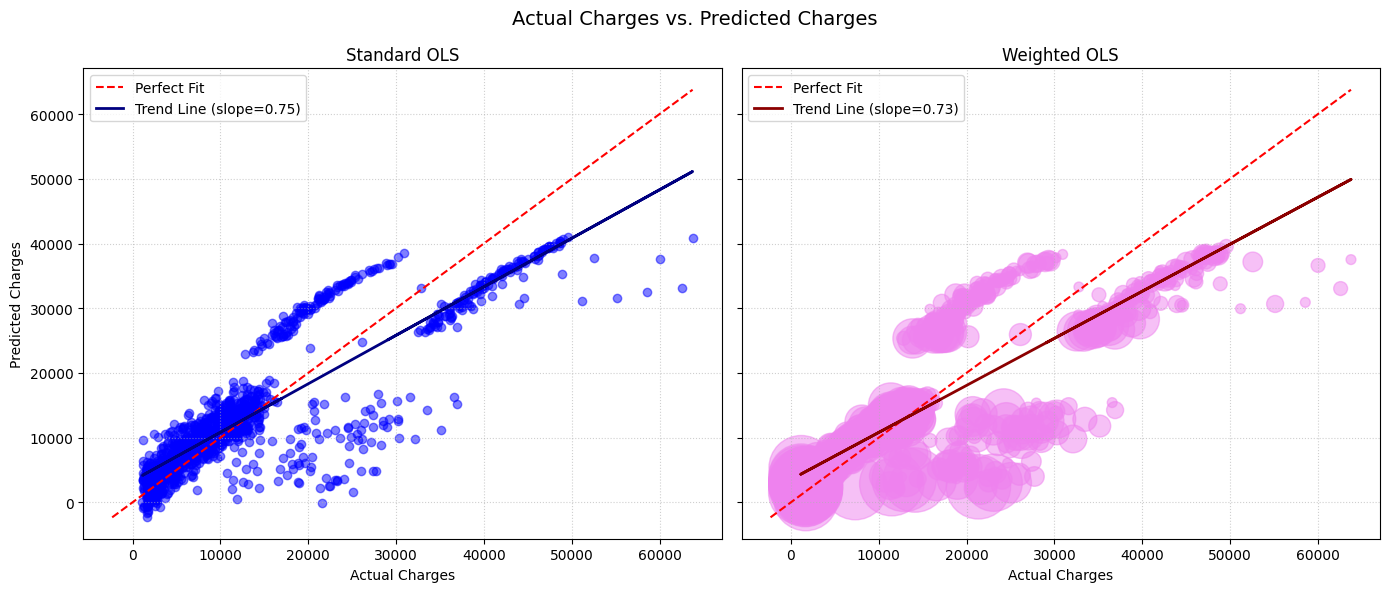

In [46]:
# set common axes limits for uniform scale
min_val = min(y.min(), y_hat.min(), y_hat_weighted.min())
max_val = max(y.max(), y_hat.max(), y_hat_weighted.max())

# create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Standard OLS plot
axes[0].scatter(
    y,
    y_hat,
    alpha=0.5,
    color='blue'
)
# Perfect Line
axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Fit')

# Fit line
m_ols, b_ols = np.polyfit(y, y_hat, 1)  # Fit line: y = mx + b
axes[0].plot(y, m_ols * y + b_ols, color='navy', linewidth=2, label=f'Trend Line (slope={m_ols:.2f})')

axes[0].set_title("Standard OLS")
axes[0].set_xlabel("Actual Charges")
axes[0].set_ylabel("Predicted Charges")
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend()

# Weighted OLS plot
axes[1].scatter(
    y,
    y_hat_weighted,
    s=beta * 50,
    alpha=0.5,
    color='violet'
)
# Perfect line
axes[1].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Fit')

# Fit line
m_w, b_w = np.polyfit(y, y_hat_weighted, 1)
axes[1].plot(y, m_w * y + b_w, color='darkred', linewidth=2, label=f'Trend Line (slope={m_w:.2f})')

axes[1].set_title("Weighted OLS")
axes[1].set_xlabel("Actual Charges")
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend()

# Layout adjustment
plt.suptitle("Actual Charges vs. Predicted Charges", fontsize=14)
plt.tight_layout()
plt.show()

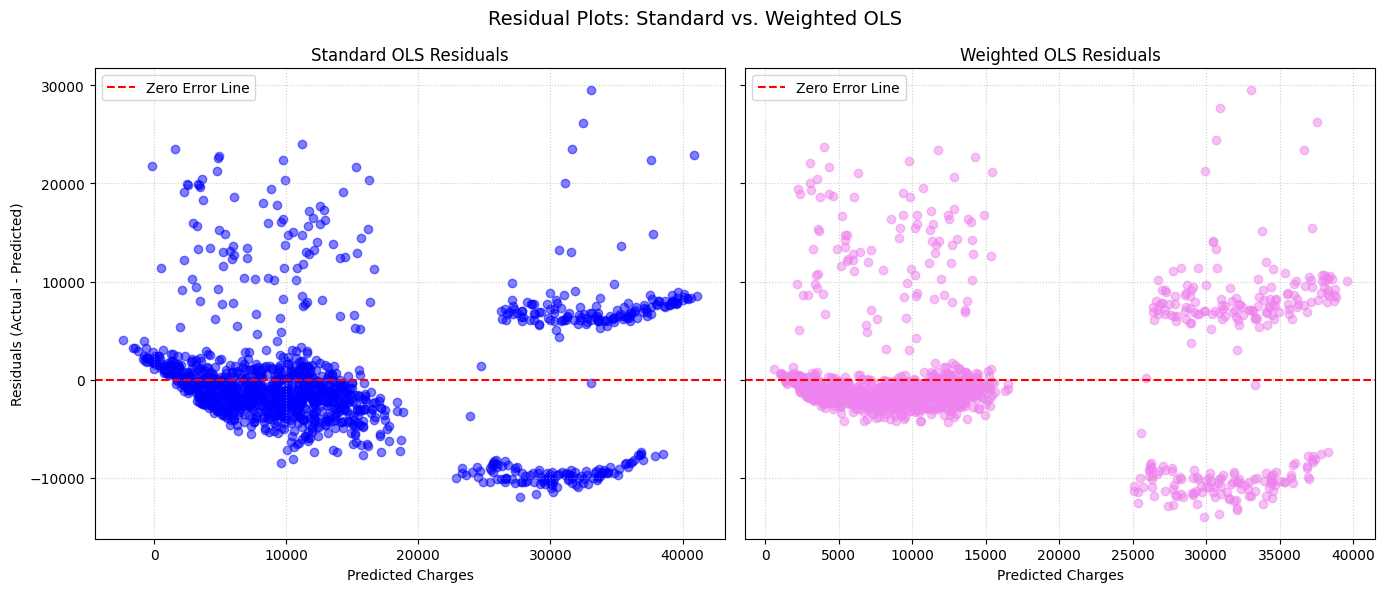

In [49]:
# calculate residuals
e_ols = y - y_hat
e_weighted = y - y_hat_weighted

# create subplots para side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Standard OLS Residuals
axes[0].scatter(
    y_hat,
    e_ols,
    alpha=0.5,
    color='blue'
)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Error Line')
axes[0].set_title("Standard OLS Residuals")
axes[0].set_xlabel("Predicted Charges")
axes[0].set_ylabel("Residuals (Actual - Predicted)")
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend()

# Weighted OLS Residuals
axes[1].scatter(
    y_hat_weighted,
    e_weighted,
    alpha=0.5,
    color='violet'
)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Error Line')
axes[1].set_title("Weighted OLS Residuals")
axes[1].set_xlabel("Predicted Charges")
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend()

plt.suptitle("Residual Plots: Standard vs. Weighted OLS", fontsize=14)
plt.tight_layout()
plt.show()

## Analytical Questions:
1. Comparing your model's MSE, RMSE, and MAE values, why is RMSE preferred when communicating medical cost errors in USD to non-technical stakeholders, and how does MAE respond differently to high-cost outlier patients?

> These three metrics are used by analysts to evaluate the performance of their models in predicting their variables, each with its own strengths and weaknesses as metrics. The metric RMSE is best used when communicating to non-technical people as it has the same units as the response variable, thus making it easier to understand. The metric MAE responds linearly to high-cost outlier patients. This means that the way it penalizes errors is proportional to their absolute size, leading to a much accurate and intuitive interpretation of the results.

2.  If you add additional uninformative demographic features to your regression model, what happens to the standard R-squared score versus Adjusted R-squared? How does Adjusted R-squared penalize extra predictors $p$?

> The R-squared score evaluates how well the explanatory variables are in explaining the response variables (e.g., a high score means the variance of the dependent variable is mostly explained by the independent variable). However, by adding uninformative independent variables, the regular R-squared score always increases. To respond to this, the Adjusted R-squared metric takes into account the number of predictor variables and decreases the score if the addition of new predictor variabels are not significant enough.

3. Attributes like age and children are discrete integers, duplicate patient profiles exist in `insurance.csv`. Why must these duplicate records not be discarded, and how does assigning weight factors $\beta_{p}$ improve model training?

> Firstly, the presence of duplicate records are often not because of data entry errors but because of natural statistical phenomenon. Removing these duplicate samples could lead your analysis to be incomplete and biased. By retaining these records and assigning weight factors $\beta_{p}$ to them, we allow the algorithm to balance underrepresented profiles and have a boost in the optimization efficiency in the computation.